<a href="https://colab.research.google.com/github/dharshinikumaravel2004-byte/ecg-classification-alexnet/blob/main/kl_divergence_alexnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from keras.models import Model
from keras.layers import Input
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
TRAIN_PATH = "/content/drive/MyDrive/mit dataset/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/mit dataset/mitbih_test.csv"

In [ ]:
train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


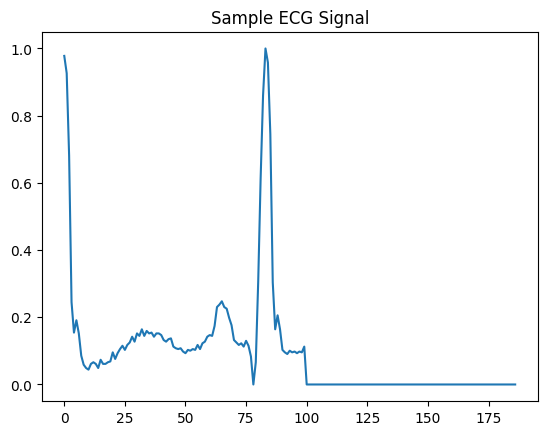

In [ ]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

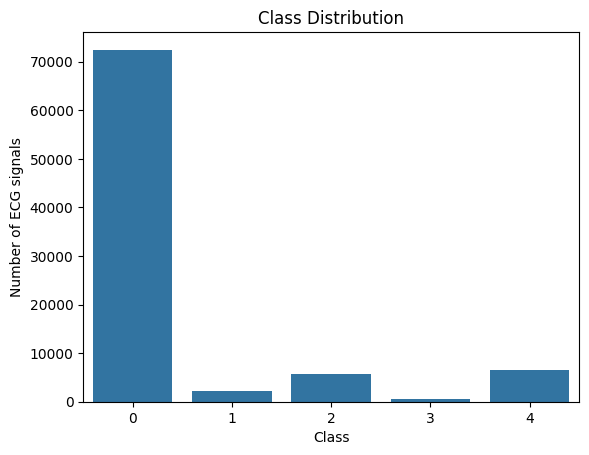

In [ ]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")

plt.show()

In [ ]:
print(train.isna().sum().sum())
print(test.isna().sum().sum())

0
0


In [ ]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

In [ ]:
print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [ ]:
X_res = X_res[:120000]
y_res = y_res[:120000]

In [ ]:
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [ ]:
X_train = np.array(X_train).reshape(-1,187,1)
X_val   = np.array(X_val).reshape(-1,187,1)
X_test  = np.array(X_test).reshape(-1,187,1)

In [ ]:
def alexnet_ecg():

    inputs = Input(shape=(187,1))

    x = Conv1D(96, kernel_size=11, strides=4, activation='relu')(inputs)
    x = MaxPooling1D(pool_size=3, strides=2)(x)

    x = Conv1D(256, kernel_size=5, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=3, strides=2)(x)

    x = Conv1D(384, kernel_size=3, activation='relu', padding='same')(x)
    x = Conv1D(384, kernel_size=3, activation='relu', padding='same')(x)
    x = Conv1D(256, kernel_size=3, activation='relu', padding='same')(x)

    x = MaxPooling1D(pool_size=3, strides=2)(x)

    x = Flatten()(x)

    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(5, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
    optimizer='adam',
    loss='kl_divergence',
    metrics=['accuracy']
)

    return model

In [ ]:
model = alexnet_ecg()
print("Loss:", model.loss)

Loss: kl_divergence


In [ ]:
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_accuracies = []

X_res = np.array(X_res).reshape(-1,187,1)
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res, y_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr = to_categorical(y_res[train_idx], 5)
    y_va = to_categorical(y_res[val_idx], 5)

    model = alexnet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=128,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    cv_accuracies.append(acc)
print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 293s 454ms/step - accuracy: 0.8603 - loss: 0.3872
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 319s 450ms/step - accuracy: 0.9478 - loss: 0.1530
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 277s 444ms/step - accuracy: 0.9640 - loss: 0.1085
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 268s 429ms/step - accuracy: 0.9728 - loss: 0.0829
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 328s 439ms/step - accuracy: 0.9779 - loss: 0.0683
Fold 1 Accuracy: 0.9793

Fold 2
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 277s 439ms/step - accuracy: 0.8495 - loss: 0.4107
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 270s 431ms/step - accuracy: 0.9504 - loss: 0.1468
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 280s 448ms/step - accuracy: 0.9668 - loss: 0.0999
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 271s 434ms/step - accuracy: 0.9741 - loss: 0.0785
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 274s 439ms/step - accuracy: 0.9793 - loss: 0.0648
Fold 2 Accuracy: 0.9793

Fold 3
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
model = alexnet_ecg()
print(model.loss)

kl_divergence


In [ ]:
y_val_pred = np.argmax(model.predict(X_val), axis=1)
y_val_true = np.argmax(y_val, axis=1)

mcc = matthews_corrcoef(y_val_true, y_val_pred)

print("Validation MCC:", mcc)

750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step
Validation MCC: 0.960353072219361


In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 357s 474ms/step - accuracy: 0.9813 - loss: 0.0577 - val_accuracy: 0.9859 - val_loss: 0.0425
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 347s 462ms/step - accuracy: 0.9842 - loss: 0.0523 - val_accuracy: 0.9837 - val_loss: 0.0475
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 340s 454ms/step - accuracy: 0.9864 - loss: 0.0430 - val_accuracy: 0.9831 - val_loss: 0.0517
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 350s 466ms/step - accuracy: 0.9880 - loss: 0.0388 - val_accuracy: 0.9878 - val_loss: 0.0392
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 370s 493ms/step - accuracy: 0.9898 - loss: 0.0330 - val_accuracy: 0.9850 - val_loss: 0.0486
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 360s 480ms/step - accuracy: 0.9895 - loss: 0.0340 - val_accuracy: 0.9862 - val_loss: 0.0422
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 341s 455ms/step - accuracy: 0.9908 - loss: 0.0299 - val_accuracy: 0.9882 - val_loss: 0.0368
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 343s 457ms/step - accuracy: 0.9917 -

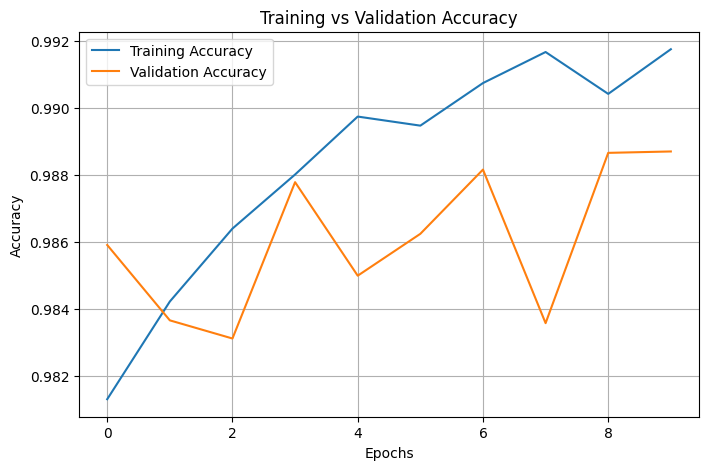

Final Training Accuracy: 0.9918
Final Validation Accuracy: 0.9887


In [ ]:
# Cell 24: Accuracy Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

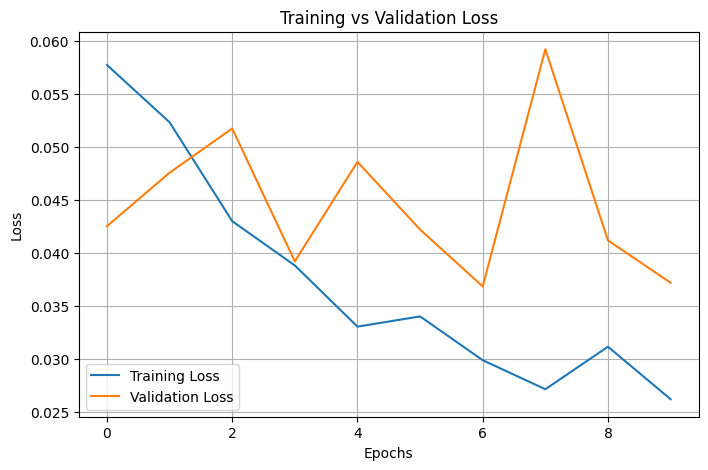

Final Training Loss: 0.0262
Final Validation Loss: 0.0372


In [ ]:
# Cell 25: Loss Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0881
Test Accuracy: 0.9786


In [ ]:
y_test_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_test_pred))

685/685 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     18118
         1.0       0.71      0.87      0.78       556
         2.0       0.97      0.93      0.95      1448
         3.0       0.74      0.75      0.75       162
         4.0       0.99      0.98      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.88      0.90      0.89     21892
weighted avg       0.98      0.98      0.98     21892



In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# Predictions
y_test_pred = np.argmax(model.predict(X_test), axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
num_classes = cm.shape[0]

# Lists
precision = []
recall = []
f1 = []
specificity = []
support = []

for i in range(num_classes):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FN + FP)

    prec = TP / (TP + FP) if (TP + FP) != 0 else 0
    rec  = TP / (TP + FN) if (TP + FN) != 0 else 0
    spec = TN / (TN + FP) if (TN + FP) != 0 else 0
    f1_score = (2 * prec * rec) / (prec + rec) if (prec + rec) != 0 else 0

    precision.append(prec)
    recall.append(rec)
    f1.append(f1_score)
    specificity.append(spec)
    support.append(np.sum(cm[i, :]))

# Convert to numpy
precision = np.array(precision)
recall = np.array(recall)
f1 = np.array(f1)
specificity = np.array(specificity)
support = np.array(support)

# Accuracy
accuracy = np.trace(cm) / np.sum(cm)

# Macro Average
macro_precision = np.mean(precision)
macro_recall = np.mean(recall)
macro_f1 = np.mean(f1)
macro_spec = np.mean(specificity)

# Weighted Average
weights = support / np.sum(support)

weighted_precision = np.sum(precision * weights)
weighted_recall = np.sum(recall * weights)
weighted_f1 = np.sum(f1 * weights)
weighted_spec = np.sum(specificity * weights)

# Create DataFrame
report_df = pd.DataFrame({
    "precision": precision,
    "recall": recall,
    "f1-score": f1,
    "specificity": specificity,
    "support": support
})

report_df.index = [f"Class {i}" for i in range(num_classes)]

# Add summary rows
summary_df = pd.DataFrame({
    "precision": [accuracy, macro_precision, weighted_precision],
    "recall":    [accuracy, macro_recall, weighted_recall],
    "f1-score":  [accuracy, macro_f1, weighted_f1],
    "specificity": [np.nan, macro_spec, weighted_spec],
    "support":   [np.sum(support), np.sum(support), np.sum(support)]
}, index=["accuracy", "macro avg", "weighted avg"])

# Combine
final_df = pd.concat([report_df, summary_df])

# Print
print(final_df.round(3))

685/685 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step
              precision  recall  f1-score  specificity  support
Class 0           0.991   0.987     0.989        0.955    18118
Class 1           0.709   0.867     0.780        0.991      556
Class 2           0.966   0.930     0.948        0.998     1448
Class 3           0.744   0.753     0.748        0.998      162
Class 4           0.994   0.984     0.989        1.000     1608
accuracy          0.979   0.979     0.979          NaN    21892
macro avg         0.881   0.904     0.891        0.988    21892
weighted avg      0.980   0.979     0.979        0.962    21892


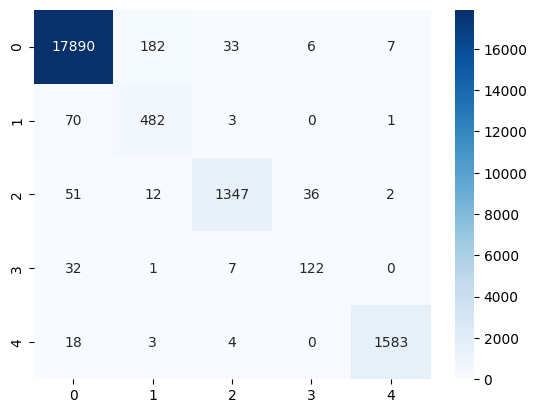

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()